# 实验1：使用Python实现逻辑回归

欢迎来到《逻辑回归》的第一个实验。

我们将学习如何使用逻辑回归模型，基于多个特征变量预测样本的分类标签。

在本实验中，我们将根据两个输入特征预测对应的二分类标签（0 或 1）。

你可以通过单击代码区域，然后使用键盘快捷键 **Shift + Enter** 来运行代码。或者在选择代码后使用 **运行** 按钮执行代码。像这样的 MarkDown 文本可以通过双击编辑，并使用这些相同的快捷键保存。

**文档中提供的代码具有顺序性，必须从前往后依次运行代码，不能跳跃执行，否则可能出现意想不到的错误！**

### 定义

逻辑回归用于解决分类问题，通过逻辑函数将线性回归的输出映射到概率空间，常用于二分类问题。  

二分类问题指的是将输入数据划分为两个互斥的类别，例如：
- 邮件分类：邮件是“垃圾邮件”（正类）或“非垃圾邮件”（负类）。
- 疾病诊断：患者“患病”（正类）或“健康”（负类）。

一般用 1 表示正类，0 表示负类。

### 公式

$P(y=1|X)=\frac{1}{1+e^{-(\beta_0+\beta_1x_1+\beta_2x_2+\dots+\beta_nx_n)}}$

解析：
- $\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$ 是线性回归（$y = wx + b$）的输出，表示特征的加权和。其中 $\beta_0$ 是截距，表示特征全为 0 时线性回归的输出。$\beta_1, \dots, \beta_n$ 是特征 $x_1, \dots, x_n$ 的系数，反映每个特征对结果的贡献。
- 逻辑函数（Sigmoid 函数）$\frac{1}{1 + e^{-z}}$ 将线性部分的输出 $z$（$z = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$）映射到 (0,1) 区间。
  - 当 $z \to +\infty$，$P(y=1|X) \to 1$。
  - 当 $z \to -\infty$，$P(y=1|X) \to 0$。
  - 当 $z=0$（即线性部分为 0），$P(y=1|X)=0.5$（分类阈值通常设为此值）。
- 输出 $P(y=1|X)$ 表示在给定特征 $X$ 下，样本属于正类（y=1）的概率。若 $P(y=1|X) \geq 0.5$，预测为 1；否则预测为 0。

### 第一步：导入所需的库

我们需要用到以下几个 Python 库：

- `numpy`：用于处理数值计算和数组操作。
- `sklearn.linear_model.LogisticRegression`：提供逻辑回归分类模型。

In [ ]:
!pip install scikit-learn numpy
from sklearn.linear_model import LogisticRegression
import numpy as np

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
  Using cached https://pypi.tuna.tsinghua.edu.cn/packages/46/1c/395a83ee7b2d2ad7a05b453872053d41449564477c81dc356f720b16eac4/sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

### 第二步：准备样本数据

我们使用 NumPy 数组创建样本数据，其中：

- 自变量 `X`：包含两个特征变量的二维数组。
- 因变量 `y`：二分类标签的一维数组（0 或 1）。

In [8]:
# 样本数据（X为输入特征，y为二分类标签）
X = np.array([[1, 2], [2, 3], [4, 5], [6, 7]])
y = np.array([0, 0, 1, 1]) 

这里的特征矩阵 X 包含 4 个样本，每个样本有 2 个特征。目标变量 y 是对应的二分类标签。

### 第三步：创建并训练逻辑回归模型

使用 LogisticRegression() 创建模型，并通过 fit() 方法训练模型。

In [9]:
# 创建逻辑回归模型
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

### 第四步：使用模型进行预测

通过 predict() 方法，输入新的特征值来预测样本的分类标签。

In [10]:
# 预测
y_pred = model.predict(np.array([[7, 8]]))
print(f"预测类别: {y_pred}")

预测类别: [1]


# 实验2：信用卡风险审批系统

在金融行业中，银行需要评估申请人是否存在违约风险，从而决定是否通过贷款或信用卡申请。

在本实验中，我们将学习如何使用逻辑回归的基本形式和Sigmoid函数来估算申请人发生违约的概率，从而帮助系统作出审批决策。

### 第一步：导入必要的Python库

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

### 第二步：定义评分系统参数与逻辑回归函数

我们预设一个逻辑回归模型的系数，模拟真实审批场景下影响违约风险的五个因素：

- `debt_ratio`：债务比率（越高风险越大）
- `monthly_income`：月收入（越高风险越小）
- `education`：教育水平（间接衡量履约能力）
- `delinquency`：历史违约次数（直接影响信用）

使用逻辑回归公式：
$$ \text{Probability} = \frac{1}{1 + e^{-z}} $$
其中：$z = w_0 + w_1 x_1 + w_2 x_2 + ... + w_n x_n$

In [12]:
coefficients = {
    "intercept": -2,
    "debt_ratio": 0.5,
    "monthly_income": -0.8,
    "education": -0.3,
    "delinquency": 0.6
}

def calculate_probability(features):
    z = (coefficients['intercept'] +
         coefficients['debt_ratio'] * features['debt_ratio'] +
         coefficients['monthly_income'] * features['monthly_income'] +
         coefficients['education'] * features['education'] +
         coefficients['delinquency'] * features['delinquency'])
    return 1 / (1 + np.exp(-z))

### 第三步：输入模拟客户数据，预测违约概率

In [13]:
applicants = [
    {"name": "张三", "debt_ratio": 0.5, "monthly_income": 2, "education": 4, "delinquency": 2},
    {"name": "李四", "debt_ratio": 0.5, "monthly_income": 1, "education": 3, "delinquency": 3},
    {"name": "王五", "debt_ratio": 1, "monthly_income": 1, "education": 2, "delinquency": 4},
    {"name": "赵六", "debt_ratio": 1.5, "monthly_income": 0.5, "education": 1, "delinquency": 4}
]

for applicant in applicants:
    applicant["default_prob"] = calculate_probability(applicant)

### 第四步：结果可视化 - Sigmoid函数 + 各客户违约概率

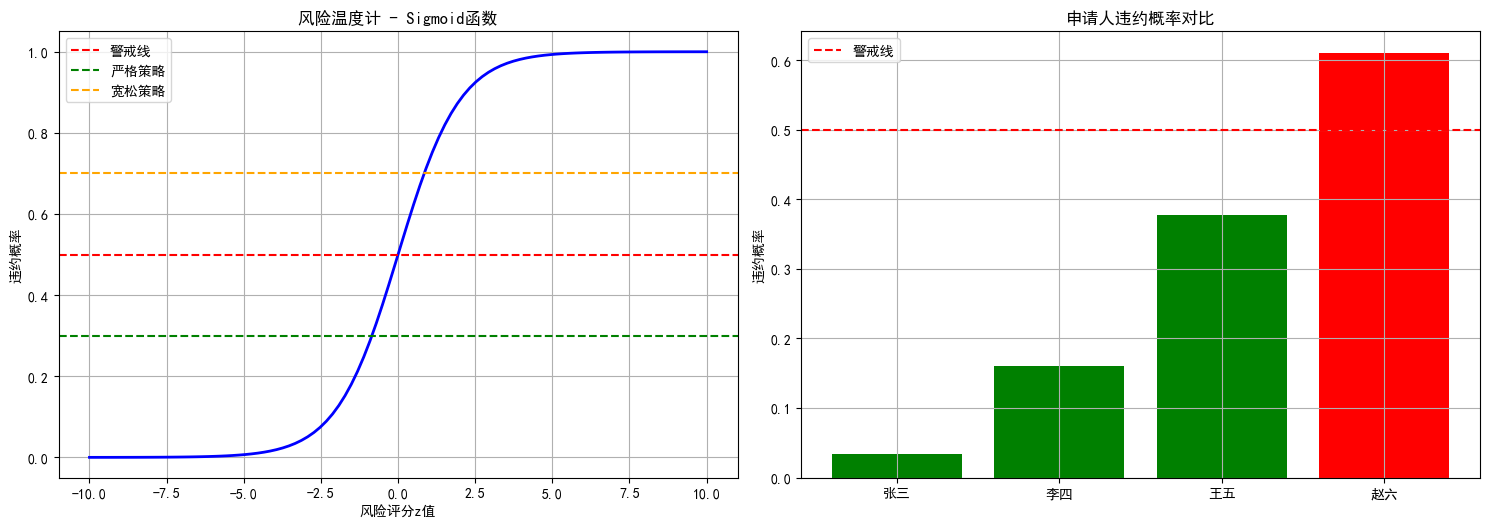

In [ ]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体作为默认字体以支持中文
plt.rcParams['axes.unicode_minus'] = False    # 解决保存图像时负号'-'显示为方块的问题

plt.figure(figsize=(15, 10))
gs = GridSpec(2, 2, figure=plt.gcf())

# Sigmoid函数曲线
ax1 = plt.subplot(gs[0, 0])
x = np.linspace(-10, 10, 100)
y = 1 / (1 + np.exp(-x))
ax1.plot(x, y, color='blue', linewidth=2)
ax1.axhline(y=0.5, color='red', linestyle='--', label='警戒线')
ax1.axhline(y=0.3, color='green', linestyle='--', label='严格策略')
ax1.axhline(y=0.7, color='orange', linestyle='--', label='宽松策略')
ax1.set_title("风险温度计 - Sigmoid函数")
ax1.set_xlabel("风险评分z值")
ax1.set_ylabel("违约概率")
ax1.legend()
ax1.grid(True)

# 各申请人违约概率柱状图
ax2 = plt.subplot(gs[0, 1])
names = [a["name"] for a in applicants]
probs = [a["default_prob"] for a in applicants]
bars = ax2.bar(names, probs, color=['red' if p > 0.5 else 'green' for p in probs])
ax2.axhline(y=0.5, color='red', linestyle='--', label='警戒线')
ax2.set_title("申请人违约概率对比")
ax2.set_ylabel("违约概率")
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

### 🤔 思考与讨论

**Q1：你认为违约概率超过多少时应拒绝审批？是0.5还是更高或更低？为什么？**

**Q2：这个评分系统是否公平？是否应该根据不同用户群体调整权重？**

**Q3：哪些额外变量（如婚姻、职位、年龄）可能也影响信用风险？如何引入模型？**

# 实验3：电商用户流失预警系统

在电商平台运营中，识别可能即将流失的用户对于提升留存率和复购率至关重要。

通过对用户最近的行为特征（如登录频率、购物车放弃率等）进行建模，我们可以预测哪些用户可能即将流失，从而提前进行干预。

本实验中，我们将使用逻辑回归模型来建立一个用户流失预警系统，并结合图形进行结果解释与评估。

### 第一步：导入所需的库与模拟数据

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

我们准备一个包含8位用户的模拟行为数据集，每个用户记录了4个特征变量：

- 最近登录频率（次/周）
- 购物车放弃率（放入购物车但未结算的比例）
- 优惠券使用比例
- 客单价环比变化

标签部分标记用户为“活跃”或“流失”

In [ ]:
data = pd.DataFrame({
    "最近登录频率": [7, 3, 2, 5, 2, 1, 4, 4],
    "购物车放弃率": [0.1, 0.5, 0.8, 0.3, 0.7, 0.9, 0.2, 0.4],
    "优惠券使用比例": [0.8, 0.6, 0.2, 0.7, 0.3, 0.1, 0.9, 0.5],
    "客单价环比变化": [0.1, -0.2, -0.5, 0.0, -0.3, -0.6, 0.2, -0.1],
    "标签": ["活跃", "活跃", "流失", "活跃", "休眠", "流失", "活跃", "活跃"]
})

### 第二步：准备特征与目标变量

In [ ]:
X = data[["最近登录频率", "购物车放弃率", "优惠券使用比例", "客单价环比变化"]]
y = data["标签"].map({"流失": 1, "活跃": 0, "休眠": 1})  # 将"流失"和"休眠"映射为1，将"活跃"映射为0

### 第三步：模型训练

我们使用逻辑回归模型进行训练，将数据随机划分为训练集和测试集，比例为7:3。

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression(solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### 第四步：模型预测与结果评估

In [ ]:
test_logits = model.decision_function(X_test)
sigmoid_probs = 1 / (1 + np.exp(-test_logits))
predicted_classes = (sigmoid_probs >= 0.5).astype(int) # 将概率值大于或等于0.5的样本预测为类别1，小于0.5的样本预测为类别0

print("分类报告：")
print(classification_report(y_test, predicted_classes, target_names=["活跃", "流失"]))

分类报告：
              precision    recall  f1-score   support

          活跃       1.00      1.00      1.00         2
          流失       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### 第五步：绘制混淆矩阵

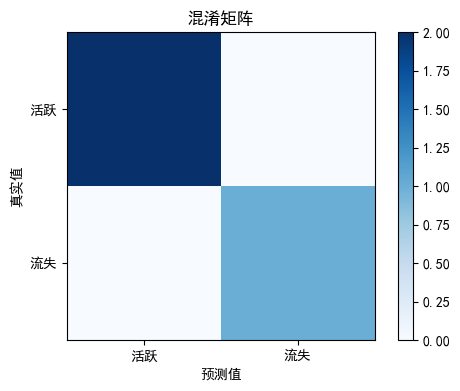

In [ ]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体作为默认字体以支持中文
plt.rcParams['axes.unicode_minus'] = False    # 解决保存图像时负号'-'显示为方块的问题

cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("混淆矩阵")
plt.colorbar()
plt.xlabel("预测值")
plt.ylabel("真实值")
plt.xticks([0, 1], ["活跃", "流失"])
plt.yticks([0, 1], ["活跃", "流失"])
plt.show()

### 第六步：使用测试用户绘制决策边界图

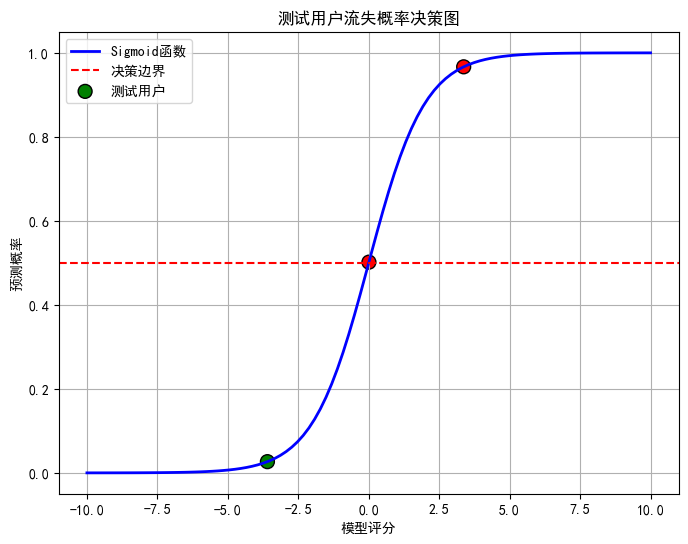

In [ ]:
test_data = pd.DataFrame({
    "最近登录频率": [6, 3, 0],
    "购物车放弃率": [0.2, 0.7, 0.9],
    "优惠券使用比例": [0.9, 0, 0.1],
    "客单价环比变化": [0.2, -0.1, -0.6]
})
test_logits = model.decision_function(test_data)
test_probs = 1 / (1 + np.exp(-test_logits))

x = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8, 6))
plt.plot(x, sigmoid, color='blue', linewidth=2, label='Sigmoid函数')
plt.axhline(y=0.5, color='red', linestyle='--', label='决策边界')
colors = ['green' if p < 0.5 else 'red' for p in test_probs]
plt.scatter(test_logits, test_probs, c=colors, s=100, edgecolors='black', label='测试用户')
plt.title("测试用户流失概率决策图")
plt.xlabel("模型评分")
plt.ylabel("预测概率")
plt.legend()
plt.grid(True)
plt.show()

如果要调整决策的阈值，应该如何改动？改动之后图像会发生什么样的改变？

### 🤔 思考与讨论

**Q1：你认为哪些行为变量对用户是否流失最关键？你会如何选择更多特征？**

**Q2：你能否设想一个推荐策略，用于将可能流失的用户“唤醒”？**

**Q3：除了逻辑回归，你还能想到哪些方法用于用户分类或行为建模？**

## 📝 实验总结

本次我们完成了两个真实业务背景下的二分类任务：

- **信用卡风险审批系统**：基于评分函数与Sigmoid输出，预测客户违约风险；
- **用户流失预警系统**：基于用户行为特征，通过逻辑回归构建预测模型。

**你已经掌握的技能包括：**
- 构造特征和标签变量；
- 使用逻辑回归进行模型训练与预测；
- 使用Sigmoid函数理解模型输出概率；
- 绘制分类边界与评估图像（如混淆矩阵、评分图）。

**建议你在后续学习中尝试：**
- 学习特征工程与正则化方法优化模型；
- 对模型结果进行业务解释与风险评估；
- 尝试使用支持向量机、随机森林等方法提升模型表现。

继续努力，逐步掌握更强大的数据分析与建模能力！